In [24]:
# ### 📦 Résumé du pipeline complet
# ```
# Données brutes (768 patients, 8 variables)
#         ↓
#    Split 80/20
#         ↓
#    Train (614)          Test (154)
#         ↓                    ↓
#   StandardScaler.fit()   StandardScaler.transform()
#   StandardScaler.transform()   (même moyenne que train)
#         ↓
#      SMOTE
#   (seulement sur train)
#         ↓
#   Train final (800)      Test final (154)
#   {0:400, 1:400}         {0:100, 1:54}  ← reste réel
#         ↓
#   Entraîner les modèles ML 🚀

In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("data\diabetes_dataset.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from imblearn.over_sampling import SMOTE
from collections import Counter

# Chargement du dataset
df = pd.read_csv("data\diabetes_dataset.csv")  # adapte le nom si besoin

print("Shape:", df.shape)
print("\nAperçu:")
df.head()

Shape: (768, 9)

Aperçu:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("=== INFO ===")
print(df.info())

print("\n=== STATISTIQUES ===")
print(df.describe())

print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== DOUBLONS ===")
print(f"Nombre de doublons : {df.duplicated().sum()}")

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None


=== STATISTIQUES ===
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.00

In [10]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important pour garder la même proportion de classes
)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"\nDistribution classes - Train :\n{y_train.value_counts()}")
print(f"\nDistribution classes - Test  :\n{y_test.value_counts()}")

Train : (614, 8)  |  Test : (154, 8)

Distribution classes - Train :
Outcome
0    400
1    214
Name: count, dtype: int64

Distribution classes - Test  :
Outcome
0    100
1     54
Name: count, dtype: int64


In [11]:
# Le scaler est FIT uniquement sur le train → pas de fuite d'info vers le test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Reconvertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Exemple après standardisation (train) :")
X_train_scaled.head()

Exemple après standardisation (train) :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-0.980131,-0.404784,-0.553973,-0.331319,-0.607678,0.310794,-0.792169
1,0.356576,0.161444,0.465368,0.392787,-0.526398,-0.302139,-0.116439,0.561034
2,-0.549372,-0.504474,-0.622322,1.213312,0.142444,0.372594,-0.764862,-0.707594
3,-0.851355,0.795653,-0.731091,-1.311380,-0.730766,-0.289408,0.262314,-0.369293
4,-1.153338,-0.821579,-0.296015,1.150195,0.244628,1.607482,-0.337630,-0.961320


=== Distribution des classes dans le TRAIN ===
  Classe 0 : 400 (65.1%)
  Classe 1 : 214 (34.9%)


C:\Users\toufi\AppData\Local\Temp\ipykernel_25584\4096953459.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="Set2")


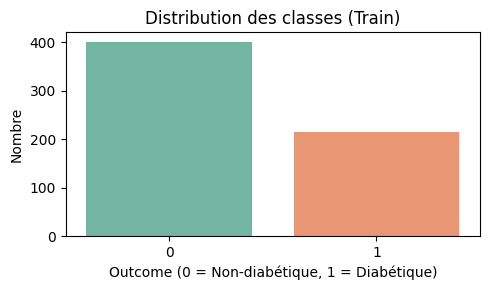


Ratio classe 0 / classe 1 : 1.87
⚠️  Déséquilibre détecté → SMOTE recommandé


In [12]:
counter = Counter(y_train)
total = len(y_train)

print("=== Distribution des classes dans le TRAIN ===")
for cls, count in counter.items():
    print(f"  Classe {cls} : {count} ({count/total*100:.1f}%)")

# Visualisation
plt.figure(figsize=(5, 3))
sns.countplot(x=y_train, palette="Set2")
plt.title("Distribution des classes (Train)")
plt.xlabel("Outcome (0 = Non-diabétique, 1 = Diabétique)")
plt.ylabel("Nombre")
plt.tight_layout()
plt.show()

# Ratio
ratio = counter[0] / counter[1]
print(f"\nRatio classe 0 / classe 1 : {ratio:.2f}")
if ratio > 1.5:
    print("⚠️  Déséquilibre détecté → SMOTE recommandé")
else:
    print("✅  Classes équilibrées → SMOTE non nécessaire")

In [18]:
from imblearn.over_sampling import SMOTE

In [19]:
# SMOTE appliqué UNIQUEMENT sur le train (jamais sur le test)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("=== Avant SMOTE ===")
print(Counter(y_train))

print("\n=== Après SMOTE ===")
print(Counter(y_train_resampled))

print(f"\nShape X_train après SMOTE : {X_train_resampled.shape}")

=== Avant SMOTE ===
Counter({0: 400, 1: 214})

=== Après SMOTE ===
Counter({0: 400, 1: 400})

Shape X_train après SMOTE : (800, 8)


In [21]:
print("="*45)
print("       RÉCAPITULATIF DONNÉES FINALES")
print("="*45)
print(f"X_train (après SMOTE) : {X_train_resampled.shape}")
print(f"y_train (après SMOTE) : {Counter(y_train_resampled)}")
print(f"\nX_test (standardisé)  : {X_test_scaled.shape}")
print(f"y_test                : {Counter(y_test)}")
print("\n✅ Données prêtes pour l'entraînement des modèles !")

       RÉCAPITULATIF DONNÉES FINALES
X_train (après SMOTE) : (800, 8)
y_train (après SMOTE) : Counter({0: 400, 1: 400})

X_test (standardisé)  : (154, 8)
y_test                : Counter({0: 100, 1: 54})

✅ Données prêtes pour l'entraînement des modèles !


In [25]:
# 1. X_train_resampled → convertir en DataFrame si pas déjà fait
train_df = pd.DataFrame(X_train_resampled, columns=X.columns)
train_df["Outcome"] = y_train_resampled.values

# 2. X_test_scaled → convertir en DataFrame
test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
test_df["Outcome"] = y_test.values

# 3. Sauvegarde
train_df.to_csv("data/train_ml.csv", index=False)
test_df.to_csv("data/test_ml.csv", index=False)

# 4. Vérification
print("=== train_ml.csv ===")
print(f"Shape : {train_df.shape}")
print(train_df.head(3))

print("\n=== test_ml.csv ===")
print(f"Shape : {test_df.shape}")
print(test_df.head(3))

=== train_ml.csv ===
Shape : (800, 9)
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.851355 -0.980131      -0.404784      -0.553973 -0.331319 -0.607678   
1     0.356576  0.161444       0.465368       0.392787 -0.526398 -0.302139   
2    -0.549372 -0.504474      -0.622322       1.213312  0.142444  0.372594   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.310794 -0.792169        0  
1                 -0.116439  0.561034        0  
2                 -0.764862 -0.707594        0  

=== test_ml.csv ===
Shape : (154, 9)
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.960541  1.207888      -0.296015      -1.311380 -0.730766 -0.582217   
1     1.866489 -1.677760       1.988135       0.140318 -0.275582  0.448979   
2    -0.549372  0.034603       0.356599       0.392787  1.127127  0.499902   

   DiabetesPedigreeFunction       Age  Outcome  
0                 -0.555791  0.561034        0  
1   

# pour LLM

In [26]:
# On travaille sur les données ORIGINALES (pas standardisées)
# Les LLM comprennent mieux les vraies valeurs médicales (ex: Glucose=148, pas 0.35)

X_train_original = X_train.copy()
X_train_original["Outcome"] = y_train.values

X_test_original = X_test.copy()
X_test_original["Outcome"] = y_test.values

In [27]:
def convert_to_text(row):
    label = "diabetic" if row["Outcome"] == 1 else "not diabetic"
    text = (
        f"The patient is {int(row['Age'])} years old. "
        f"She had {int(row['Pregnancies'])} pregnancies. "
        f"Her glucose level is {row['Glucose']}. "
        f"Her blood pressure is {row['BloodPressure']}. "
        f"Her skin thickness is {row['SkinThickness']}. "
        f"Her insulin level is {row['Insulin']}. "
        f"Her BMI is {row['BMI']}. "
        f"Her diabetes pedigree function is {row['DiabetesPedigreeFunction']}. "
        f"Based on these values, the patient is {label}."
    )
    return text

In [28]:
# Conversion en texte
train_texts = X_train_original.apply(convert_to_text, axis=1)
test_texts  = X_test_original.apply(convert_to_text, axis=1)

In [29]:
# Aperçu
print("=== EXEMPLE TEXTE (1 patient) ===\n")
print(train_texts.iloc[0])
print(f"\nNombre de textes train : {len(train_texts)}")
print(f"Nombre de textes test  : {len(test_texts)}")

=== EXEMPLE TEXTE (1 patient) ===

The patient is 24 years old. She had 1 pregnancies. Her glucose level is 90.0. Her blood pressure is 62.0. Her skin thickness is 12.0. Her insulin level is 43.0. Her BMI is 27.2. Her diabetes pedigree function is 0.58. Based on these values, the patient is not diabetic.

Nombre de textes train : 614
Nombre de textes test  : 154


In [30]:
train_texts

353    The patient is 24 years old. She had 1 pregnan...
711    The patient is 40 years old. She had 5 pregnan...
373    The patient is 25 years old. She had 2 pregnan...
46     The patient is 29 years old. She had 1 pregnan...
682    The patient is 22 years old. She had 0 pregnan...
                             ...                        
451    The patient is 23 years old. She had 2 pregnan...
113    The patient is 25 years old. She had 4 pregnan...
556    The patient is 30 years old. She had 1 pregnan...
667    The patient is 40 years old. She had 10 pregna...
107    The patient is 37 years old. She had 4 pregnan...
Length: 614, dtype: object

In [31]:
test_texts

44     The patient is 40 years old. She had 7 pregnan...
672    The patient is 47 years old. She had 10 pregna...
700    The patient is 26 years old. She had 2 pregnan...
630    The patient is 34 years old. She had 7 pregnan...
81     The patient is 22 years old. She had 2 pregnan...
                             ...                        
32     The patient is 22 years old. She had 3 pregnan...
637    The patient is 23 years old. She had 2 pregnan...
593    The patient is 25 years old. She had 2 pregnan...
425    The patient is 31 years old. She had 4 pregnan...
273    The patient is 21 years old. She had 1 pregnan...
Length: 154, dtype: object